# EDA - Dataset Maestro

Análisis exploratorio de datos para detección de riesgos de corrupción.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [2]:
BASE = Path(r"C:\IA_Investigacion\Deteccion_Corrupcion")
DATASET = BASE / "data" / "processed" / "dataset_maestro_v2_4niveles.parquet"

df = pd.read_parquet(DATASET)

print(df.shape)
df.head()

(324, 93)


,IDENTIFICADOR_OBRA,obra_PROCESO_mean,obra_PROCESO_max,obra_PROCESO_min,obra_CODIGO_RUC_GANADOR_mean,obra_CODIGO_RUC_GANADOR_max,obra_CODIGO_RUC_GANADOR_min,obra_CONVOCATORIA_PROCESO_GANADO_mean,obra_CONVOCATORIA_PROCESO_GANADO_max,obra_CONVOCATORIA_PROCESO_GANADO_min,...,obra_NUMERO_CONTRATO_nunique,obra_NOMBRE_PARTICIPANTE_first,obra_NOMBRE_PARTICIPANTE_nunique,y_riesgo_obra_4niveles,func_n_registros,func_n_funcionarios,func_riesgo_max,func_riesgo_mean,func_riesgo_std,func_pct_riesgo_alto
0,2002060-2434-702592-2064311-19777,3.0,3,3,2.054932e+10,20549322434,20549322434,702592.0,702592,702592,...,1,VERA & MORENO S.A. CONSULTORES DE INGENIERIA(*),6,3,6.0,6.0,3.0,1.166667,1.329160,0.166667
1,2002210-8880-869397-2169938-826,60.0,60,60,2.052240e+10,20522404331,20522404331,869397.0,869397,869397,...,1,consorcio consultor peajes,14,2,12.0,6.0,0.0,0.000000,0.000000,0.000000
2,2002210-8880-870112-2169901-826,60.0,60,60,2.052898e+10,20528975055,20528975055,870112.0,870112,870112,...,1,consorcio consultor peajes,13,2,0.0,0.0,0.0,0.000000,0.000000,0.000000
3,2026767-16256-709096-2067605-143536,14.0,14,14,2.041669e+10,20419183220,20414192531,709096.0,709096,709096,...,1,KUKOVA INGENIEROS S.A.C.(*),10,3,6.0,6.0,3.0,0.500000,1.224745,0.166667
4,2027711-3876-682536-2050524-138320,39.0,39,39,2.055223e+10,20552233787,20552233787,682536.0,682536,682536,...,1,LAGESA INGENIEROS CONSULTORES S.A.,22,3,12.0,11.0,3.0,0.666667,1.230915,0.166667


## Información general

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 324 entries, 0 to 323
Data columns (total 93 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   IDENTIFICADOR_OBRA                                      324 non-null    object 
 1   obra_PROCESO_mean                                       324 non-null    float64
 2   obra_PROCESO_max                                        324 non-null    int64  
 3   obra_PROCESO_min                                        324 non-null    int64  
 4   obra_CODIGO_RUC_GANADOR_mean                            324 non-null    float64
 5   obra_CODIGO_RUC_GANADOR_max                             324 non-null    int64  
 6   obra_CODIGO_RUC_GANADOR_min                             324 non-null    int64  
 7   obra_CONVOCATORIA_PROCESO_GANADO_mean                   324 non-null    float64
 8   obra_CONVOCATORIA_PROCESO_GANADO_max    

## Estadísticas descriptivas

In [4]:
df.describe()

,obra_PROCESO_mean,obra_PROCESO_max,obra_PROCESO_min,obra_CODIGO_RUC_GANADOR_mean,obra_CODIGO_RUC_GANADOR_max,obra_CODIGO_RUC_GANADOR_min,obra_CONVOCATORIA_PROCESO_GANADO_mean,obra_CONVOCATORIA_PROCESO_GANADO_max,obra_CONVOCATORIA_PROCESO_GANADO_min,obra_TotalProcesosParticipantes_mean,...,obra_RAZON_SOCIAL_nunique,obra_NUMERO_CONTRATO_nunique,obra_NOMBRE_PARTICIPANTE_nunique,y_riesgo_obra_4niveles,func_n_registros,func_n_funcionarios,func_riesgo_max,func_riesgo_mean,func_riesgo_std,func_pct_riesgo_alto
count,324.000000,324.000000,324.000000,3.240000e+02,3.240000e+02,3.240000e+02,324.000000,324.000000,324.000000,324.000000,...,324.000000,324.0,324.000000,324.0,324.000000,324.000000,324.000000,324.000000,324.000000,324.000000
mean,18.901235,18.901235,18.901235,1.787149e+10,1.851035e+10,1.723818e+10,735331.762346,735331.762346,735331.762346,93.203807,...,6.910494,1.0,6.910494,2.123457,4.941358,4.064815,0.953704,0.279425,0.416054,0.078224
std,40.053325,40.053325,40.053325,4.104754e+09,4.046701e+09,4.736962e+09,90767.221621,90767.221621,90767.221621,80.185541,...,8.098543,0.0,8.098543,1.003186,5.928857,4.187420,1.376838,0.489668,0.614104,0.149414
min,1.000000,1.000000,1.000000,1.001160e+10,1.001160e+10,1.000105e+10,385171.000000,385171.000000,385171.000000,1.000000,...,1.000000,1.0,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,3.000000,3.000000,1.532828e+10,2.011726e+10,1.040899e+10,671243.250000,671243.250000,671243.250000,39.000000,...,2.000000,1.0,2.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.500000,6.500000,6.500000,2.042512e+10,2.051968e+10,2.030139e+10,719921.000000,719921.000000,719921.000000,79.750000,...,4.000000,1.0,4.000000,2.0,6.000000,6.000000,0.000000,0.000000,0.000000,0.000000
75%,19.000000,19.000000,19.000000,2.053869e+10,2.060054e+10,2.052290e+10,807329.750000,807329.750000,807329.750000,129.625000,...,9.000000,1.0,9.000000,3.0,7.000000,6.000000,3.000000,0.500000,1.167748,0.148810
max,539.000000,539.000000,539.000000,2.061056e+10,2.061056e+10,2.061056e+10,933575.000000,933575.000000,933575.000000,577.500000,...,52.000000,1.0,52.000000,3.0,55.000000,18.000000,3.000000,2.500000,1.732051,0.833333


## Valores faltantes

In [5]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(20)

obra_monto_ofertado_std_max                        72
obra_monto_ofertado_std_min                        72
obra_monto_ofertado_std_mean                       72
obra_obra_2b_n_registros_mean                      67
obra_obra_2b_nunique_DNI_MIEMBRO_COMITE_min        67
obra_obra_2b_nunique_NOMBRE_MIEMBRO_COMITE_min     67
obra_obra_2b_nunique_NOMBRE_MIEMBRO_COMITE_max     67
obra_obra_2b_nunique_NOMBRE_MIEMBRO_COMITE_mean    67
obra_obra_2b_n_registros_max                       67
obra_obra_2b_nunique_DNI_MIEMBRO_COMITE_max        67
obra_obra_2b_nunique_DNI_MIEMBRO_COMITE_mean       67
obra_obra_2b_n_registros_min                       67
IDENTIFICADOR_OBRA                                  0
obra_CODIGO_CONTRATO_mean                           0
obra_CODIGO_CONTRATO_max                            0
obra_CODIGO_CONTRATO_min                            0
obra_CODIGO_RUC_PARTICIPANTE_mean                   0
obra_PROCESO_mean                                   0
obra_PROCESO_max            

##  Distribución del target

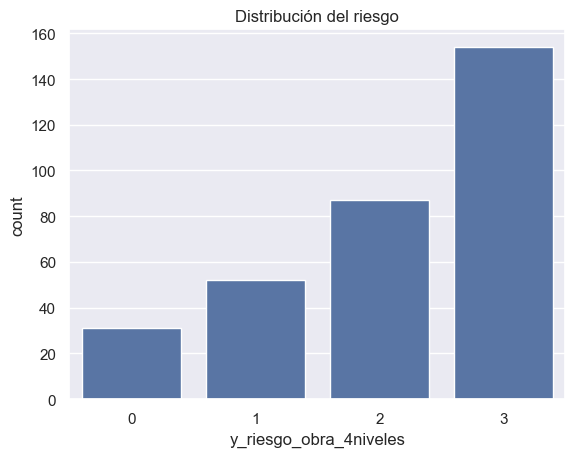

y_riesgo_obra_4niveles
3    0.475309
2    0.268519
1    0.160494
0    0.095679
Name: proportion, dtype: Float64

In [6]:
TARGET = "y_riesgo_obra_4niveles"

sns.countplot(x=df[TARGET])
plt.title("Distribución del riesgo")
plt.show()

df[TARGET].value_counts(normalize=True)

## Distribución de variables numéricas

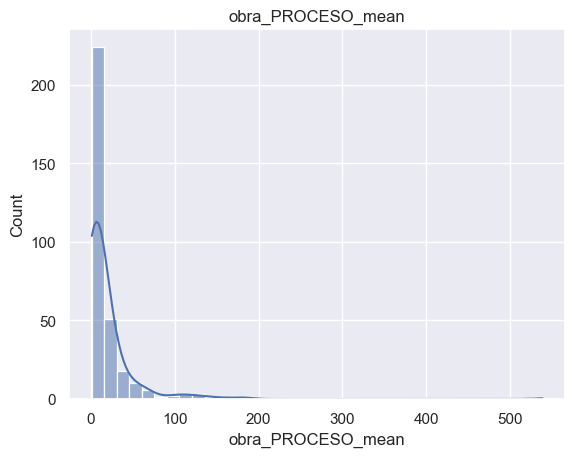

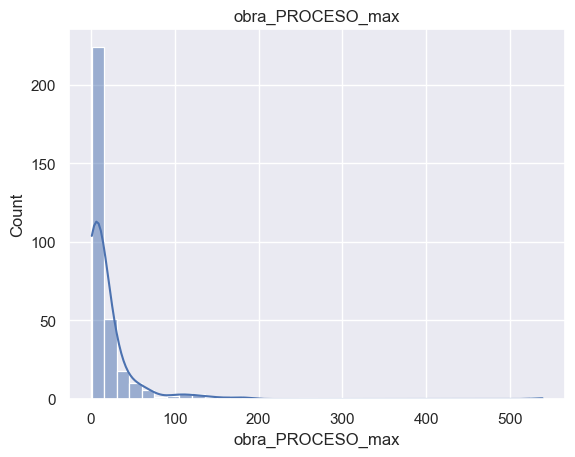

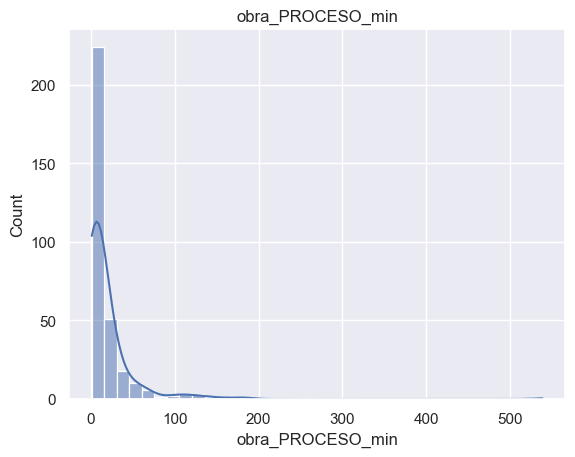

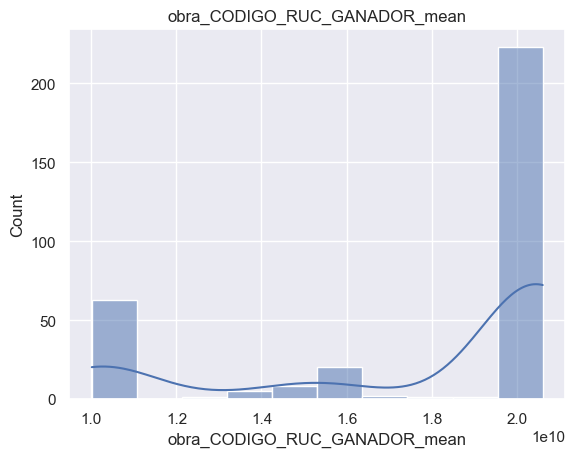

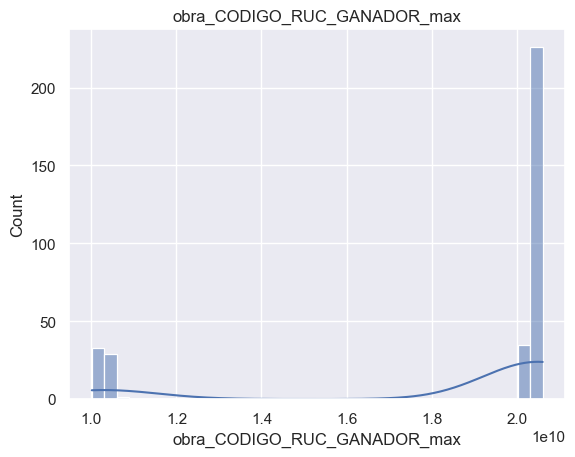

In [7]:
num_cols = df.select_dtypes(include=["number"]).columns

for col in num_cols[:5]:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

## Outliers (Boxplots)

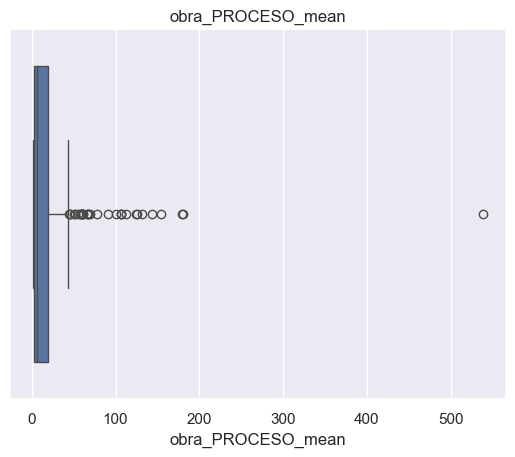

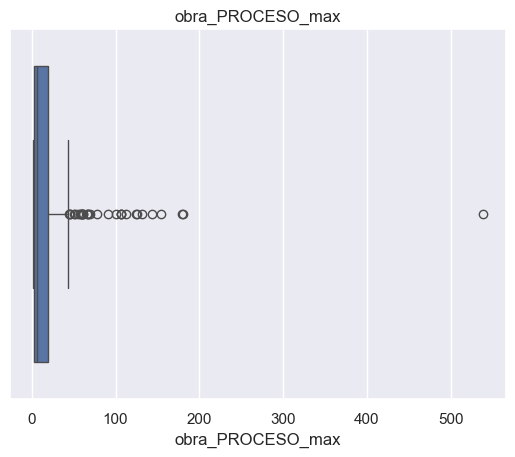

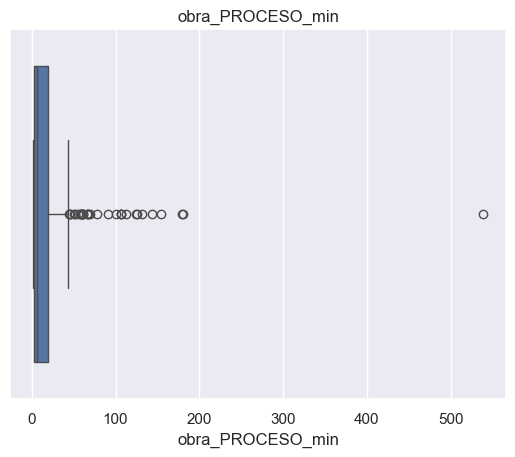

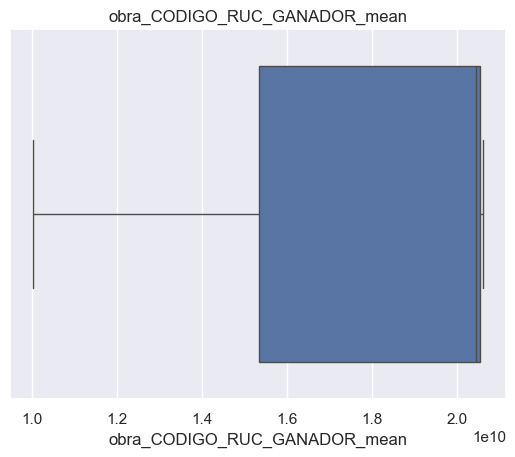

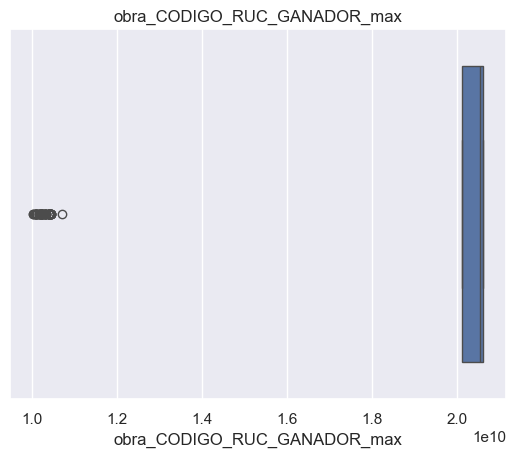

In [8]:
for col in num_cols[:5]:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

## Correlación

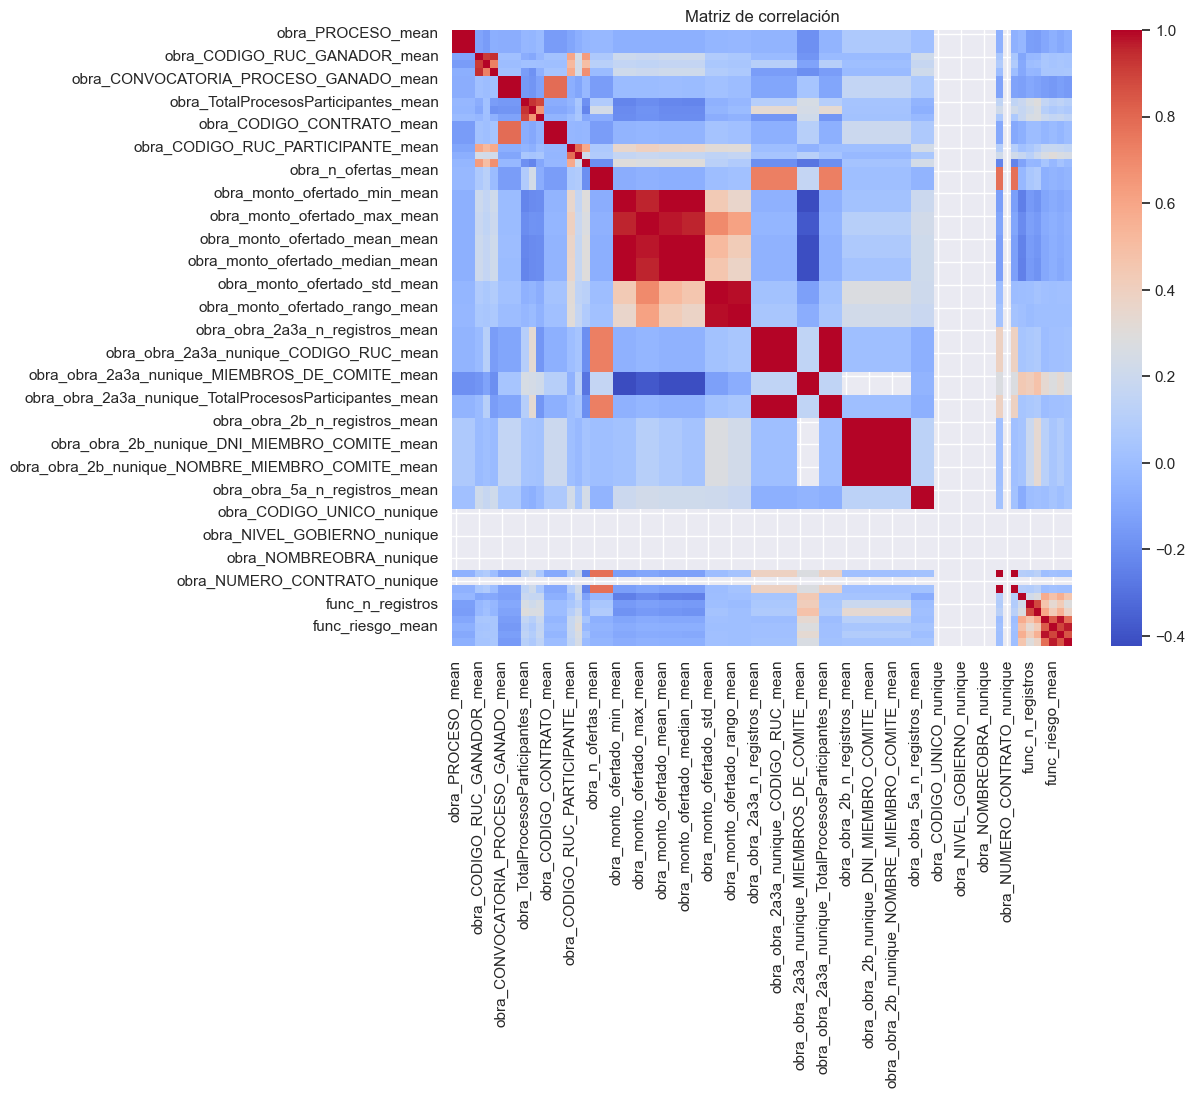

In [9]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matriz de correlación")
plt.show()

## Riesgos identificados

- **Desbalance de clases:** distribución desigual del target
- **Data leakage:** variables derivadas del riesgo eliminadas
- **Drift:** posible cambio en el tiempo (no medido aún)
